In [1]:

# imports
import os
import sys
import types
import json

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = fig_dpi
  from IPython.display import set_matplotlib_formats
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  pio.renderers.default = "notebook_connected"
except Exception:
  pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass



# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
if r'/Users/legoses/Library/CloudStorage/GoogleDrive-nelsonla@byui.edu/My Drive/Lance/PH150/book/labs/Lab5-Experimental-Design-I':
  os.chdir(r'/Users/legoses/Library/CloudStorage/GoogleDrive-nelsonla@byui.edu/My Drive/Lance/PH150/book/labs/Lab5-Experimental-Design-I')

# reset state
%reset

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v
  
  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define


{"/opt/homebrew/Cellar/python@3.11/3.11.6/Frameworks/Python.framework/Versions/3.11/lib/python3.11/importlib/_bootstrap.py": 1696254354.0, "/opt/homebrew/Cellar/python@3.11/3.11.6/Frameworks/Python.framework/Versions/3.11/lib/python3.11/importlib/_bootstrap_external.py": 1696254354.0, "/opt/homebrew/Cellar/python@3.11/3.11.6/Frameworks/Python.framework/Versions/3.11/lib/python3.11/zipimport.py": 1696254354.0, "/opt/homebrew/Cellar/python@3.11/3.11.6/Frameworks/Python.framework/Versions/3.11/lib/python3.11/codecs.py": 1696254354.0, "/opt/homebrew/Cellar/python@3.11/3.11.6/Frameworks/Python.framework/Versions/3.11/lib/python3.11/encodings/aliases.py": 1696254354.0, "/opt/homebrew/Cellar/python@3.11/3.11.6/Frameworks/Python.framework/Versions/3.11/lib/python3.11/encodings/__init__.py": 1696254354.0, "/opt/homebrew/Cellar/python@3.11/3.11.6/Frameworks/Python.framework/Versions/3.11/lib/python3.11/encodings/utf_8.py": 1696254354.0, "/opt/homebrew/Cellar/python@3.11/3.11.6/Frameworks/Python.

/var/folders/l7/qksjftz12pz0s32y0l3jd4k4cyyb65/T/ipykernel_17453/3479806967.py:20: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats(fig_format)


Text(0.5, 1.0, 'Skid time vs initial speed')

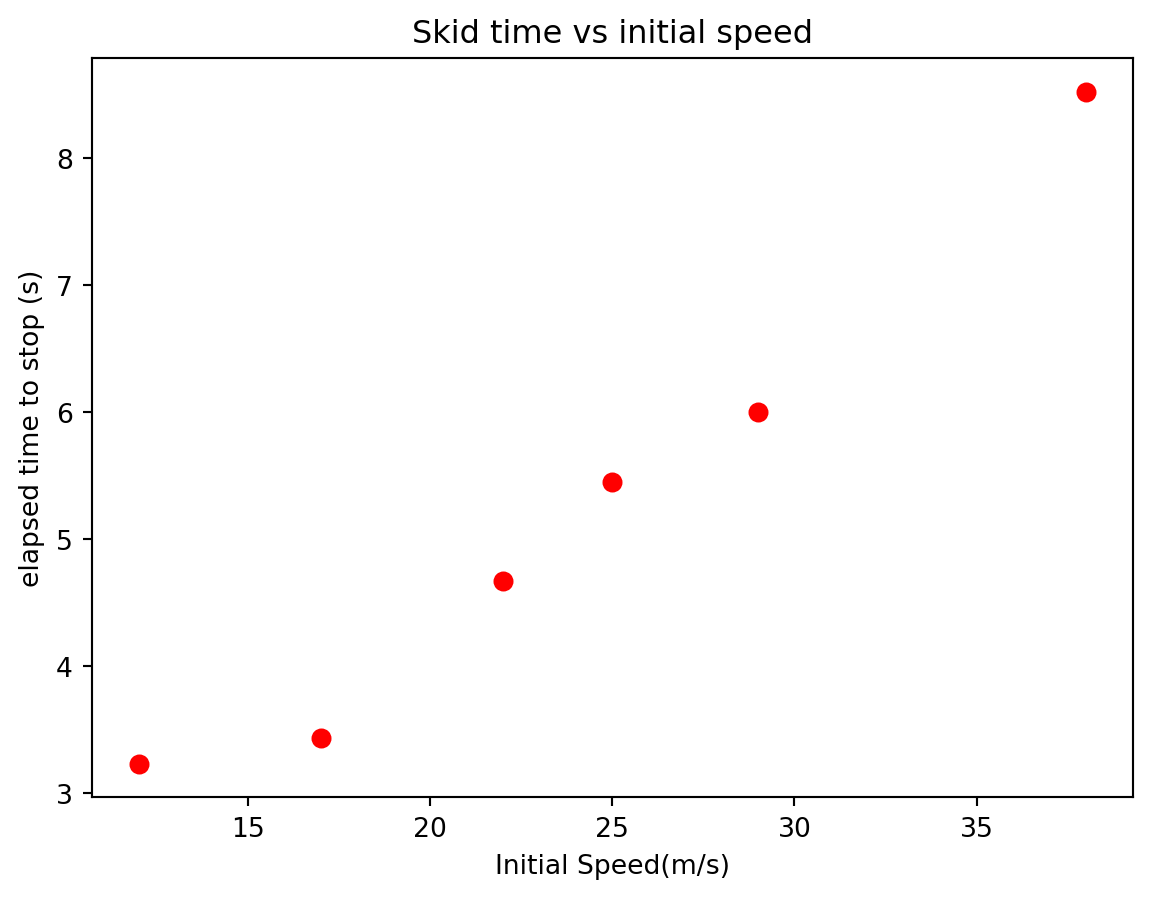

In [2]:
#| echo: false

from matplotlib import pyplot as plt

t = [3.23,3.43,4.67,5.45,6,8.52]
vi = [12,17,22,25,29,38]
plt.plot(vi,t,'r.',ms = 13)
plt.xlabel("Initial Speed(m/s)")
plt.ylabel("elapsed time to stop (s)")
plt.title("Skid time vs initial speed")

In [3]:
from matplotlib import pyplot as plt
from numpy import polyfit

t = [3.23,3.43,4.67,5.45,6,8.52]
vi = [12,17,22,25,29,38]

params = polyfit(vi,t,1)
slope = params[0]
yint = params[1]

g=9.8 #Acceleration due to gravity
mu = 1/(slope * g)
print(params)
print(mu)


[0.20971747 0.21840032]
0.48656326406696404


Text(0.5, 1.0, 'Skid time vs initial speed')

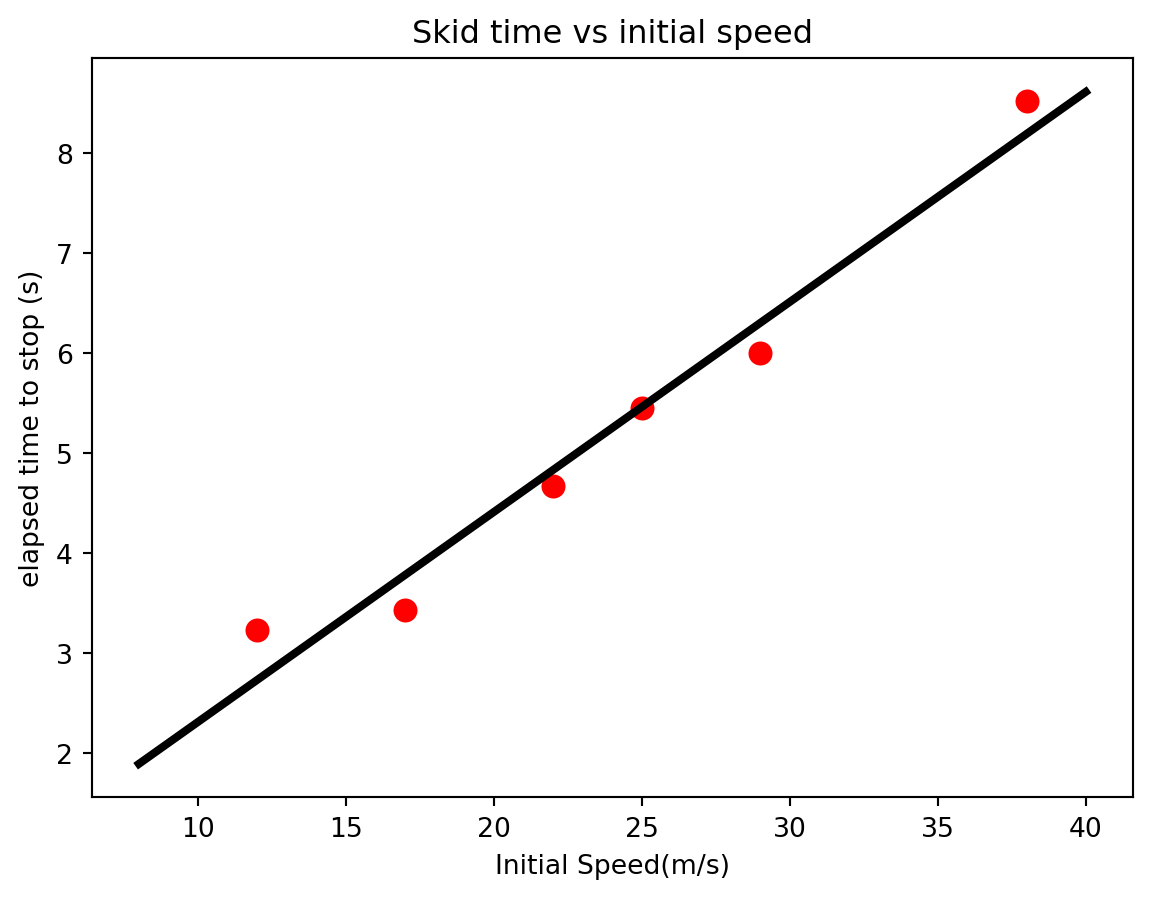

In [4]:
from matplotlib import pyplot as plt
from numpy import polyfit,linspace

t = [3.23,3.43,4.67,5.45,6,8.52]
vi = [12,17,22,25,29,38]

params = polyfit(vi,t,1)
vDense = linspace(8,40,100)
tDense = params[0] * vDense + params[1]

plt.plot(vi,t,'r.',ms = 16)
plt.plot(vDense,tDense,'k',lw = 3)
plt.xlabel("Initial Speed(m/s)")
plt.ylabel("elapsed time to stop (s)")
plt.title("Skid time vs initial speed")


In [5]:
from matplotlib import pyplot as plt
import numpy as np

t = [3.23,3.43,4.67,5.45,6,8.52]
vi = [12,17,22,25,29,38]

params = np.polyfit(vi,t,1,cov = True)
slope = params[0][0]
dslope = np.sqrt(params[1][0][0])
yint = params[0][1]
dyint = np.sqrt(params[1][1][1])

print(f"The slope is {slope:5.2f} +- {dslope:2.2f}")
print(f"The y-int is {yint:5.2f} +- {dyint:2.2f}")


The slope is  0.21 +- 0.02
The y-int is  0.22 +- 0.48


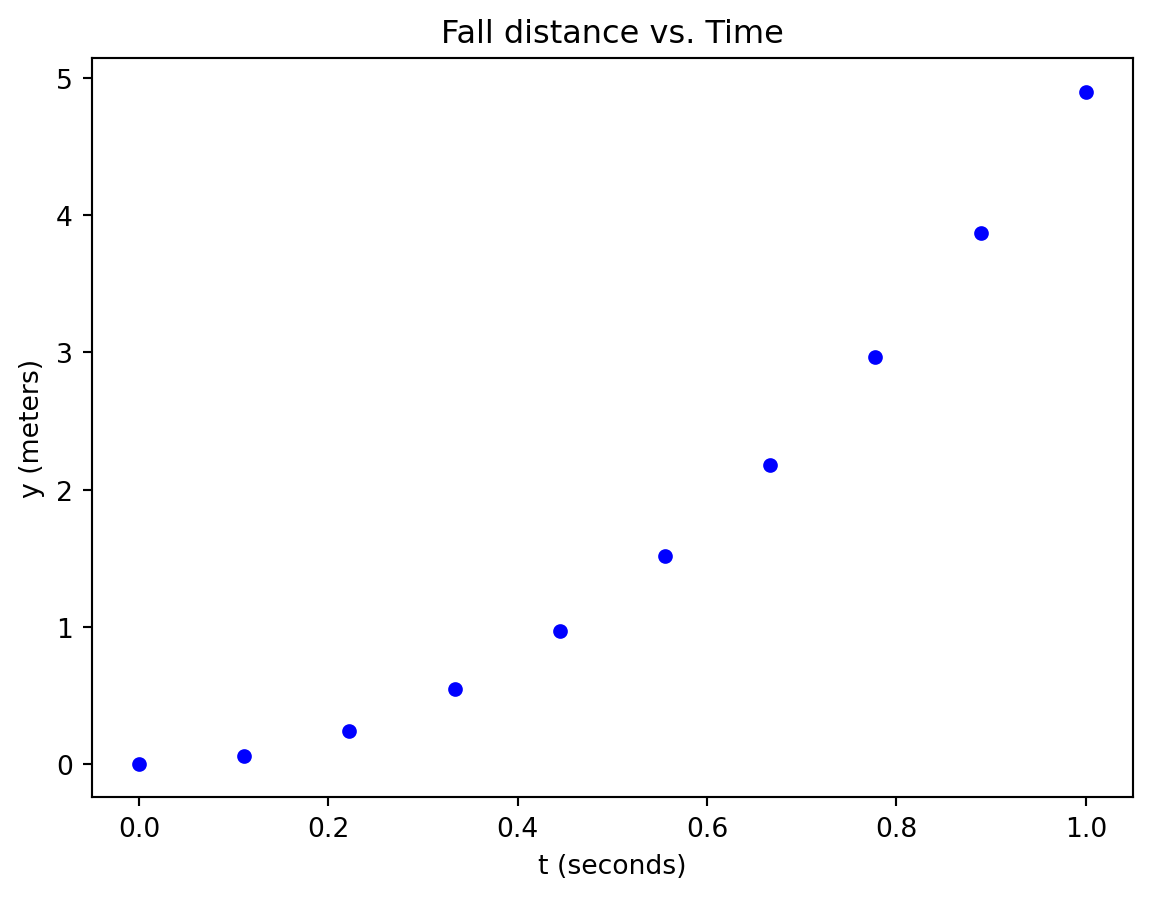

In [6]:
#| eval: True
#| echo: False
import numpy as np
import matplotlib.pyplot as plt
t = np.linspace(0,1,10)
g = 9.8
y = 1/2 * g * t**2
plt.plot(t,y,'b.',ms = 9)
plt.xlabel("t (seconds)")
plt.ylabel("y (meters)")
plt.title("Fall distance vs. Time")
plt.show()

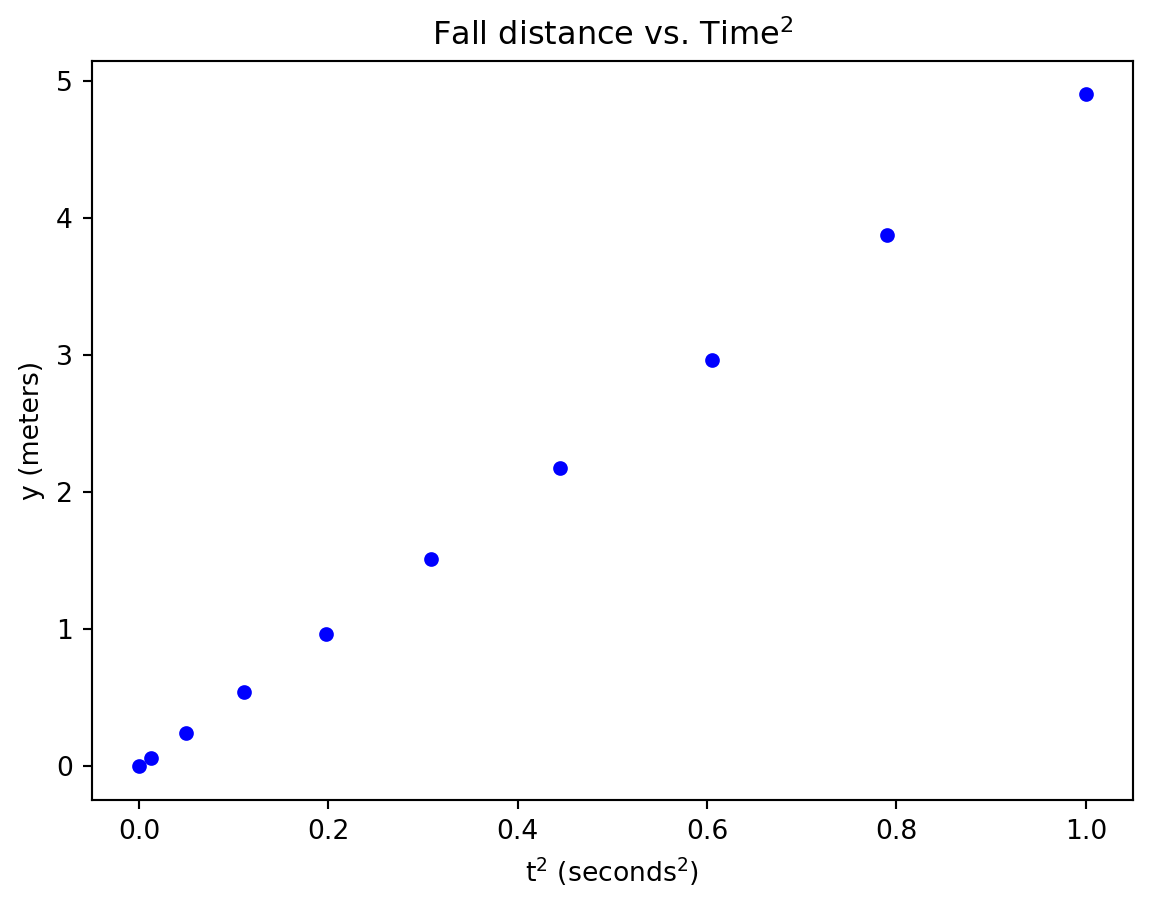

In [7]:
#| eval: True
#| echo: False
import numpy as np
import matplotlib.pyplot as plt
t = np.linspace(0,1,10)
g = 9.8
y = 1/2 * g * t**2
plt.plot(t**2,y,'b.',ms = 9)
plt.xlabel(r"t$^2$ (seconds$^2$)")
plt.ylabel("y (meters)")
plt.title(r"Fall distance vs. Time$^2$")
plt.show()

In [8]:
# Perform calculations and construct plots here.

In [9]:
# Perform calculations here